# Insurance Claim Fraud Detection — Model 2: Isolation Forest

This notebook is self-contained (repeats the shared cleaning/encoding), then trains an
**Isolation Forest** — an unsupervised anomaly-detection model — as the project's third
"perspective" on each claim, alongside the supervised Random Forest and XGBoost models.

Isolation Forest never sees `FraudFound_P` during fitting; it only isolates points that are
easy to separate from the rest of the data (few random splits needed = more anomalous). We use
the true labels only for **tuning `contamination`** and for **evaluation** — a standard way to
benchmark anomaly detectors on a labeled dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


## 1. Load data and check the fraud vs legit ratio

In [2]:
df = pd.read_csv("fraud_oracle.csv")
print("Shape:", df.shape)
counts = df['FraudFound_P'].value_counts()
pct = df['FraudFound_P'].value_counts(normalize=True) * 100
print("\nClass counts:\n", counts)
print("\nClass percentage:\n", pct.round(2))
fraud_ratio = df['FraudFound_P'].mean()
print(f"\nTrue fraud ratio in the data: {fraud_ratio*100:.2f}%")
print("This ratio is used below as the Isolation Forest 'contamination' starting point.")


Shape: (15420, 33)

Class counts:
 FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Class percentage:
 FraudFound_P
0    94.01
1     5.99
Name: proportion, dtype: float64

True fraud ratio in the data: 5.99%
This ratio is used below as the Isolation Forest 'contamination' starting point.


## 2. Cleaning (identical to the other notebooks, so results are comparable)

In [3]:
df.loc[(df['Age'] == 0) & (df['AgeOfPolicyHolder'] == '16 to 17'), 'Age'] = 17
df.loc[df['DayOfWeekClaimed'] == '0', 'DayOfWeekClaimed'] = 'Monday'
df.loc[df['MonthClaimed'] == '0', 'MonthClaimed'] = 'Jul'
df = df.drop(columns=['PolicyNumber'], errors='ignore')
print("New shape:", df.shape)


New shape: (15420, 32)


## 3. Train / test split (same random_state, so the split matches the RF/XGB notebooks)

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['FraudFound_P'])
y = df['FraudFound_P']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (12336, 31)  X_test: (3084, 31)


## 4. Feature encoding (numeric scaled, ordinal mapped, categorical one-hot)

In [5]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = ['WeekOfMonth','WeekOfMonthClaimed','Age','RepNumber','Deductible','DriverRating','Year']

ordinal_maps = {
    'Days_Policy_Accident': ['none','1 to 7','8 to 15','15 to 30','more than 30'],
    'Days_Policy_Claim':    ['none','8 to 15','15 to 30','more than 30'],
    'PastNumberOfClaims':   ['none','1','2 to 4','more than 4'],
    'AgeOfVehicle':         ['new','2 years','3 years','4 years','5 years','6 years','7 years','more than 7'],
    'AgeOfPolicyHolder':    ['16 to 17','18 to 20','21 to 25','26 to 30','31 to 35','36 to 40','41 to 50','51 to 65','over 65'],
    'NumberOfSuppliments':  ['none','1 to 2','3 to 5','more than 5'],
    'AddressChange_Claim':  ['no change','under 6 months','1 year','2 to 3 years','4 to 8 years'],
    'NumberOfCars':         ['1 vehicle','2 vehicles','3 to 4','5 to 8','more than 8'],
    'VehiclePrice':         ['less than 20000','20000 to 29000','30000 to 39000','40000 to 59000','60000 to 69000','more than 69000'],
}
ordinal_cols = list(ordinal_maps.keys())

categorical_cols = ['Month','DayOfWeek','Make','AccidentArea','DayOfWeekClaimed','MonthClaimed',
                    'Sex','MaritalStatus','Fault','PolicyType','VehicleCategory',
                    'PoliceReportFiled','WitnessPresent','AgentType','BasePolicy']

def ordinal_encode(data):
    data = data.copy()
    for col, order in ordinal_maps.items():
        data[col] = data[col].map({v: i for i, v in enumerate(order)})
    return data

X_train_ord = ordinal_encode(X_train)
X_test_ord  = ordinal_encode(X_test)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_ord[categorical_cols])
ohe_cols = ohe.get_feature_names_out(categorical_cols)
ohe_train = pd.DataFrame(ohe.transform(X_train_ord[categorical_cols]), columns=ohe_cols, index=X_train_ord.index)
ohe_test  = pd.DataFrame(ohe.transform(X_test_ord[categorical_cols]),  columns=ohe_cols, index=X_test_ord.index)

scaler = StandardScaler()
scaler.fit(X_train_ord[numeric_cols])
num_train = pd.DataFrame(scaler.transform(X_train_ord[numeric_cols]), columns=numeric_cols, index=X_train_ord.index)
num_test  = pd.DataFrame(scaler.transform(X_test_ord[numeric_cols]),  columns=numeric_cols, index=X_test_ord.index)

X_train_final = pd.concat([num_train, X_train_ord[ordinal_cols], ohe_train], axis=1)
X_test_final  = pd.concat([num_test,  X_test_ord[ordinal_cols],  ohe_test],  axis=1)

print("Final encoded shapes -> train:", X_train_final.shape, " test:", X_test_final.shape)


Final encoded shapes -> train: (12336, 104)  test: (3084, 104)


## 5. Tuning `contamination` and `n_estimators`

Isolation Forest has no `.fit(X, y)` supervision, so classic `GridSearchCV` (which needs a
classifier `.predict`) doesn't apply directly. Instead we do a manual grid search: for each
candidate `(n_estimators, contamination)` pair we fit on the **training set only**, score the
training set anomaly scores against `y_train` with **PR-AUC**, and keep the best combination.
Using PR-AUC (not accuracy) is what makes this evaluation meaningful for a ~6%-positive dataset.

In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score

candidate_n_estimators = [100, 200, 300]
candidate_contamination = [0.06, 0.10, 0.15, 0.20]  # anchored near the true 5.99% fraud ratio

results = []
for n_est in candidate_n_estimators:
    for cont in candidate_contamination:
        iso = IsolationForest(n_estimators=n_est, contamination=cont,
                               random_state=RANDOM_STATE, n_jobs=1)
        iso.fit(X_train_final)
        # more negative score_samples() = more anomalous, so flip sign -> higher = more anomalous
        train_scores = -iso.score_samples(X_train_final)
        pr_auc = average_precision_score(y_train, train_scores)
        results.append({'n_estimators': n_est, 'contamination': cont, 'train_PR_AUC': pr_auc})

results_df = pd.DataFrame(results).sort_values('train_PR_AUC', ascending=False)
print(results_df.to_string(index=False))

best_params = results_df.iloc[0]
print(f"\nBest params -> n_estimators={int(best_params['n_estimators'])}, contamination={best_params['contamination']}")


 n_estimators  contamination  train_PR_AUC
          100           0.06      0.059221
          100           0.10      0.059221
          100           0.15      0.059221
          100           0.20      0.059221
          200           0.06      0.059101
          200           0.10      0.059101
          200           0.15      0.059101
          200           0.20      0.059101
          300           0.06      0.057630
          300           0.10      0.057630
          300           0.15      0.057630
          300           0.20      0.057630

Best params -> n_estimators=100, contamination=0.06


## 6. Fit the final Isolation Forest and evaluate on the held-out test set

In [7]:
best_n_estimators = int(best_params['n_estimators'])
best_contamination = float(best_params['contamination'])

iso_final = IsolationForest(n_estimators=best_n_estimators, contamination=best_contamination,
                             random_state=RANDOM_STATE, n_jobs=1)
iso_final.fit(X_train_final)

# Anomaly score: higher = more anomalous = more "fraud-like"
if_test_score = -iso_final.score_samples(X_test_final)
# Min-max normalize to [0,1] so it behaves like a pseudo-probability, for later ensembling
if_test_proba = (if_test_score - if_test_score.min()) / (if_test_score.max() - if_test_score.min())

if_test_pred = iso_final.predict(X_test_final)          # -1 = anomaly (fraud-like), 1 = normal
if_test_pred = (if_test_pred == -1).astype(int)          # convert to 0/1 fraud flag

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

if_metrics = {
    'Precision': precision_score(y_test, if_test_pred),
    'Recall':    recall_score(y_test, if_test_pred),
    'F1':        f1_score(y_test, if_test_pred),
    'ROC-AUC':   roc_auc_score(y_test, if_test_proba),
    'PR-AUC':    average_precision_score(y_test, if_test_proba),
}
print("=== Isolation Forest — Test Set Metrics (contamination-based flag) ===")
for k, v in if_metrics.items():
    print(f"{k:10}: {v:.4f}")

print("\nClassification report:\n", classification_report(y_test, if_test_pred, target_names=['Legit','Fraud']))
print("Confusion matrix:\n", confusion_matrix(y_test, if_test_pred))


=== Isolation Forest — Test Set Metrics (contamination-based flag) ===
Precision : 0.0904
Recall    : 0.0811
F1        : 0.0855
ROC-AUC   : 0.5023
PR-AUC    : 0.0656

Classification report:
               precision    recall  f1-score   support

       Legit       0.94      0.95      0.94      2899
       Fraud       0.09      0.08      0.09       185

    accuracy                           0.90      3084
   macro avg       0.52      0.51      0.52      3084
weighted avg       0.89      0.90      0.89      3084

Confusion matrix:
 [[2748  151]
 [ 170   15]]


### Honest interpretation

Unlike Random Forest/XGBoost, Isolation Forest has **no access to the fraud label** while
learning — it only knows "does this claim's feature combination look statistically unusual".
On this dataset fraudulent claims are not necessarily *rare/unusual in feature space* (fraudsters
often mimic normal claims to blend in), so it is common and expected for Isolation Forest's
ROC-AUC to sit close to ~0.5 (little better than random) even though the supervised models score
much higher. This is a genuine, useful finding for the project write-up: it shows *why* a hybrid
system (rather than anomaly detection alone) is needed, and it's exactly the kind of
disagreement the Ensemble notebook's decision-fusion step is designed to surface for human
review, not necessarily to blindly trust.

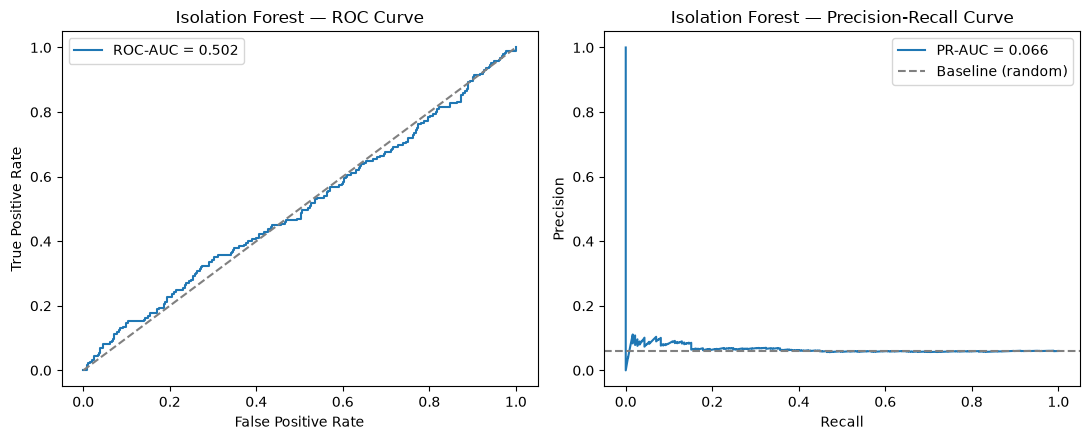

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

from sklearn.metrics import roc_curve, precision_recall_curve
fpr, tpr, _ = roc_curve(y_test, if_test_proba)
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {if_metrics['ROC-AUC']:.3f}")
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Isolation Forest — ROC Curve'); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, if_test_proba)
axes[1].plot(rec, prec, label=f"PR-AUC = {if_metrics['PR-AUC']:.3f}")
axes[1].axhline(y_test.mean(), color='gray', ls='--', label='Baseline (random)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Isolation Forest — Precision-Recall Curve'); axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Score distribution: fraud vs legit claims

A useful sanity-check plot: does the anomaly score distribution differ at all between the two
classes?

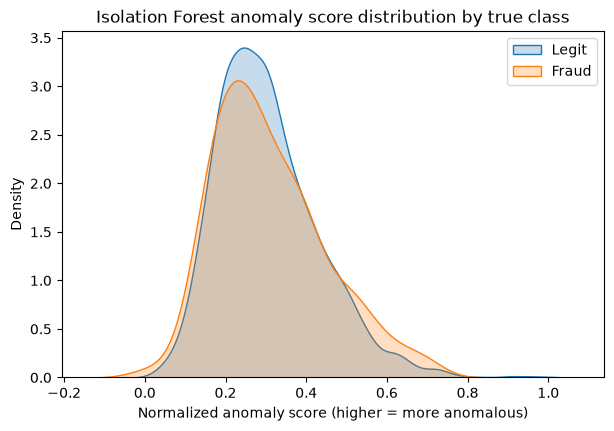

In [9]:
fig, ax = plt.subplots(figsize=(7,4.5))
sns.kdeplot(if_test_proba[y_test.values==0], label='Legit', fill=True, ax=ax)
sns.kdeplot(if_test_proba[y_test.values==1], label='Fraud', fill=True, ax=ax)
ax.set_xlabel('Normalized anomaly score (higher = more anomalous)')
ax.set_title('Isolation Forest anomaly score distribution by true class')
ax.legend()
plt.show()


## 8. Save the model + test-set scores (for the Ensemble notebook)

In [10]:
import joblib

joblib.dump(iso_final, "isolation_forest_model.pkl")

if_results = pd.DataFrame({
    'index': X_test_final.index,
    'true_label': y_test.values,
    'if_anomaly_score': if_test_score,
    'if_proba': if_test_proba,
    'if_pred': if_test_pred,
})
if_results.to_csv("if_test_predictions.csv", index=False)
print("Saved isolation_forest_model.pkl and if_test_predictions.csv")
if_results.head(10)


Saved isolation_forest_model.pkl and if_test_predictions.csv


,index,true_label,if_anomaly_score,if_proba,if_pred
0,8922,0,0.419113,0.186584,0
1,4274,0,0.435327,0.286727,0
2,3408,0,0.505696,0.721335,1
3,10675,0,0.414559,0.158459,0
4,3285,0,0.419169,0.186927,0
5,11043,0,0.427135,0.236127,0
6,3495,0,0.434275,0.280226,0
7,9299,1,0.425987,0.229041,0
8,10652,0,0.433748,0.276971,0
9,13126,0,0.442960,0.333866,0
